# Alerta 3 (Fragilidad): preparación de variables para ML

Este notebook se limita a la fase de **fragilidad** y prepara solo features para Machine Learning, sin reglas de alarma manuales.

Criterios aplicados:
- Series base: `BUSLOANS`, `PSAVERT`, `CPIAUCSL`.
- Ventana temporal: `1980-01-01` a `2025-10-01`.
- Frecuencia: mensual nativa (sin interpolación).
- Features permitidos: ratios, MA6, YoY% y rolling z-score (24 meses).
- Niveles brutos excluidos del dataset final.
- Etiqueta objetivo homogénea con otros notebooks: `Y` híbrida y horizonte de 18 meses.
- Salida final: `dataset_alerta3.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid')

START_DATE = '1980-01-01'
END_DATE = '2025-10-01'
TARGET_SHIFT_MONTHS = 18
MA_WINDOW = 6
Z_SCORE_WINDOW = 24

DATA_DIR = Path('datos ABCT')
OUTPUT_PATH = Path('dataset_alerta3.csv')

NBER_PERIODS = [
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

In [2]:
def load_monthly_series(csv_path: Path, value_col: str, date_col: str = 'observation_date') -> pd.Series:
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df[[date_col, value_col]].dropna()
    df = df.rename(columns={date_col: 'date', value_col: value_col.lower()})
    df = df.set_index('date').sort_index()
    df.index = df.index.to_period('M').to_timestamp(how='start')
    return df[value_col.lower()]


def monthly_interpolate_from_quarterly(series_q: pd.Series, start: str, end: str) -> pd.Series:
    monthly_idx = pd.date_range(start=start, end=end, freq='MS')
    return series_q.reindex(monthly_idx).interpolate(method='linear')


def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window=window, min_periods=window).mean()
    rolling_std = series.rolling(window=window, min_periods=window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)

In [3]:
monthly_index = pd.date_range(start=START_DATE, end=END_DATE, freq='MS')

busloans = load_monthly_series(DATA_DIR / 'BUSLOANS - mensual - hasta 2026.csv', 'BUSLOANS')
psavert = load_monthly_series(DATA_DIR / 'PSAVERT - Personal saving rate - hasta 2026.csv', 'PSAVERT')
cpiaucsl = load_monthly_series(DATA_DIR / 'CPIAUCSL - mensual - hasta 2026.csv', 'CPIAUCSL')

# GDPC1 solo para construir Y híbrida consistente con notebooks 1 y 2
gdpc1_q = load_monthly_series(DATA_DIR / 'GDPC1 - trimestral - hasta 01oct2025.csv', 'GDPC1')
gdpc1_m = monthly_interpolate_from_quarterly(gdpc1_q, START_DATE, END_DATE)

base = pd.DataFrame(index=monthly_index)
base['busloans'] = busloans.reindex(monthly_index)
base['psavert'] = psavert.reindex(monthly_index)
base['cpiaucsl'] = cpiaucsl.reindex(monthly_index)
base['gdpc1'] = gdpc1_m.reindex(monthly_index)

print('Rango final:', base.index.min().date(), '->', base.index.max().date())
print('Filas:', len(base))
base[['busloans', 'psavert', 'cpiaucsl']].head()

Rango final: 1980-01-01 -> 2025-10-01
Filas: 550


,busloans,psavert,cpiaucsl
1980-01-01,281.8501,9.9,78.0
1980-02-01,285.6731,10.1,79.0
1980-03-01,289.3844,10.3,80.1
1980-04-01,290.6018,11.4,80.9
1980-05-01,287.8784,11.5,81.7


In [4]:
# Y híbrida (homogénea con alerta 1 y 2)
base['gdpc1_yoy_pct'] = base['gdpc1'].pct_change(12) * 100
base['crisis_gdpc1'] = (base['gdpc1_yoy_pct'] <= 0).astype(int)

base['crisis_nber'] = 0
for start, end in NBER_PERIODS:
    mask = (base.index >= pd.Timestamp(start)) & (base.index <= pd.Timestamp(end))
    base.loc[mask, 'crisis_nber'] = 1

base['crisis_now'] = ((base['crisis_nber'] == 1) | (base['crisis_gdpc1'] == 1)).astype(int)
base['y_crisis_t_plus_18m'] = base['crisis_now'].shift(-TARGET_SHIFT_MONTHS)

# Features autorizados (sin niveles en dataset final)
base['busloans_psavert_ratio'] = base['busloans'] / base['psavert']
base['busloans_psavert_ratio_ma6'] = base['busloans_psavert_ratio'].rolling(window=MA_WINDOW, min_periods=MA_WINDOW).mean()
base['busloans_psavert_ratio_yoy_pct'] = base['busloans_psavert_ratio'].pct_change(12) * 100
base['busloans_psavert_ratio_zscore24'] = rolling_zscore(base['busloans_psavert_ratio'], window=Z_SCORE_WINDOW)

base['cpi_yoy_pct'] = base['cpiaucsl'].pct_change(12) * 100
base['cpi_yoy_pct_ma6'] = base['cpi_yoy_pct'].rolling(window=MA_WINDOW, min_periods=MA_WINDOW).mean()
base['cpi_yoy_pct_zscore24'] = rolling_zscore(base['cpi_yoy_pct'], window=Z_SCORE_WINDOW)

feature_columns = [
    'busloans_psavert_ratio',
    'busloans_psavert_ratio_ma6',
    'busloans_psavert_ratio_yoy_pct',
    'busloans_psavert_ratio_zscore24',
    'cpi_yoy_pct',
    'cpi_yoy_pct_ma6',
    'cpi_yoy_pct_zscore24',
]

model_df_3 = base[feature_columns + ['y_crisis_t_plus_18m']].copy()
model_df_3 = model_df_3.dropna()
model_df_3['y_crisis_t_plus_18m'] = model_df_3['y_crisis_t_plus_18m'].astype(int)

model_df_3.to_csv(OUTPUT_PATH, index=True, index_label='date')

print('Features finales:', len(feature_columns))
print('Observaciones útiles:', len(model_df_3))
print('Archivo exportado:', OUTPUT_PATH.resolve())
model_df_3.head()

Features finales: 7
Observaciones útiles: 497
Archivo exportado: D:\Python Projects\crisis\dataset_alerta3.csv


,busloans_psavert_ratio,busloans_psavert_ratio_ma6,busloans_psavert_ratio_yoy_pct,busloans_psavert_ratio_zscore24,cpi_yoy_pct,cpi_yoy_pct_ma6,cpi_yoy_pct_zscore24,y_crisis_t_plus_18m
1982-12-01,35.967147,33.662912,27.314535,2.194739,3.825717,5.133174,-1.852696,0
1983-01-01,35.422198,34.446029,25.778599,1.760648,3.707627,4.658215,-1.723491,0
1983-02-01,35.121036,35.154744,16.838487,1.493738,3.484688,4.244781,-1.647747,0
1983-03-01,36.804187,35.718427,22.352126,1.804285,3.590285,4.019675,-1.462799,0
1983-04-01,38.099602,36.229198,31.428746,1.917382,4.000000,3.847655,-1.196081,0


In [5]:
# Resumen descriptivo de features
feature_summary = model_df_3.describe().T
feature_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

pd.Series(feature_columns, name='feature_name')

0             busloans_psavert_ratio
1         busloans_psavert_ratio_ma6
2     busloans_psavert_ratio_yoy_pct
3    busloans_psavert_ratio_zscore24
4                        cpi_yoy_pct
5                    cpi_yoy_pct_ma6
6               cpi_yoy_pct_zscore24
Name: feature_name, dtype: str

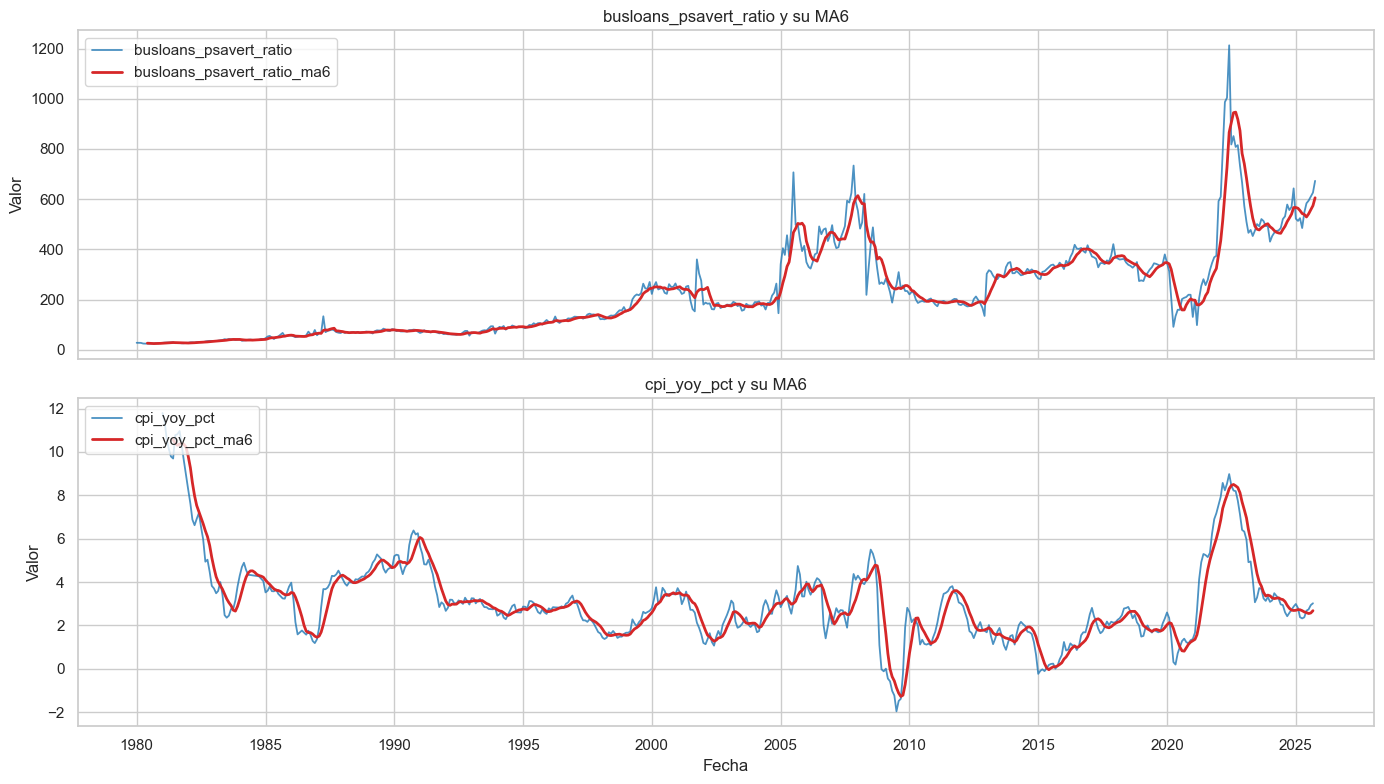

In [6]:
# Series individuales de features clave
plot_feature_pairs = [
    ('busloans_psavert_ratio', 'busloans_psavert_ratio_ma6'),
    ('cpi_yoy_pct', 'cpi_yoy_pct_ma6'),
]

fig, axes = plt.subplots(len(plot_feature_pairs), 1, figsize=(14, 8), sharex=True)

for ax, (main_col, ma_col) in zip(axes, plot_feature_pairs):
    ax.plot(base.index, base[main_col], label=main_col, linewidth=1.3, color='#1f77b4', alpha=0.8)
    ax.plot(base.index, base[ma_col], label=ma_col, linewidth=2.0, color='#d62728')
    ax.set_title(f'{main_col} y su MA6')
    ax.set_ylabel('Valor')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

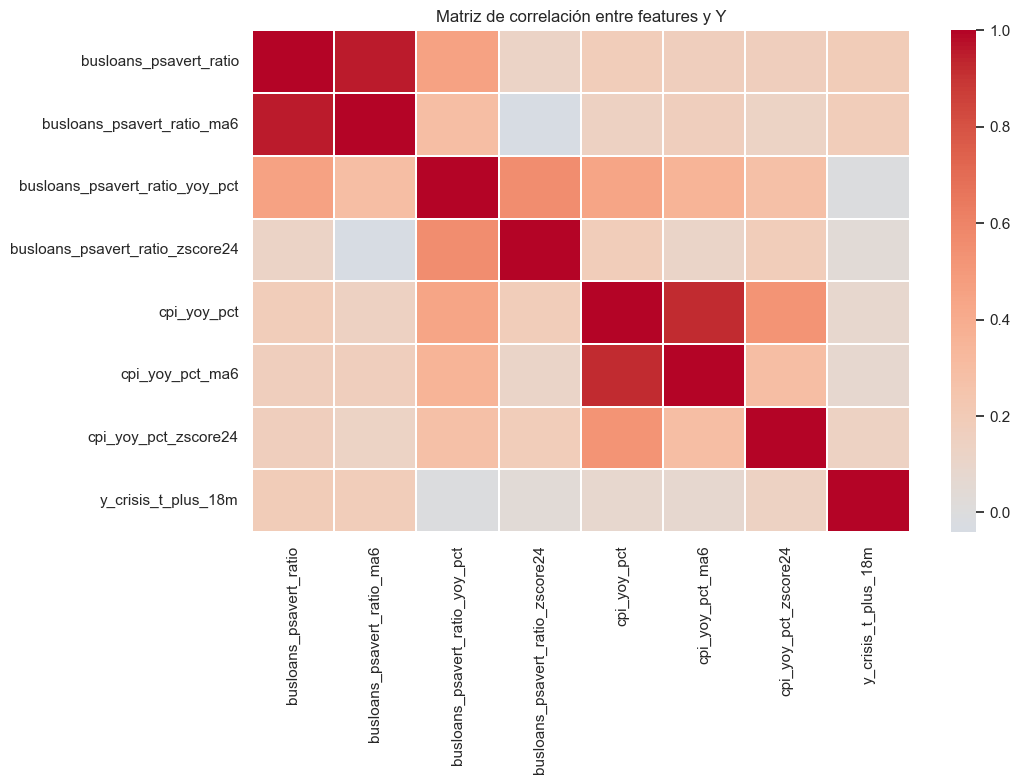

y_crisis_t_plus_18m                1.000000
busloans_psavert_ratio             0.191279
busloans_psavert_ratio_ma6         0.185276
cpi_yoy_pct_zscore24               0.136834
cpi_yoy_pct                        0.089439
cpi_yoy_pct_ma6                    0.080040
busloans_psavert_ratio_zscore24    0.032791
busloans_psavert_ratio_yoy_pct    -0.006412
Name: y_crisis_t_plus_18m, dtype: float64

In [7]:
# Matriz de correlación entre features y Y
corr_matrix = model_df_3[feature_columns + ['y_crisis_t_plus_18m']].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Matriz de correlación entre features y Y')
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix['y_crisis_t_plus_18m'].sort_values(ascending=False)
corr_with_target

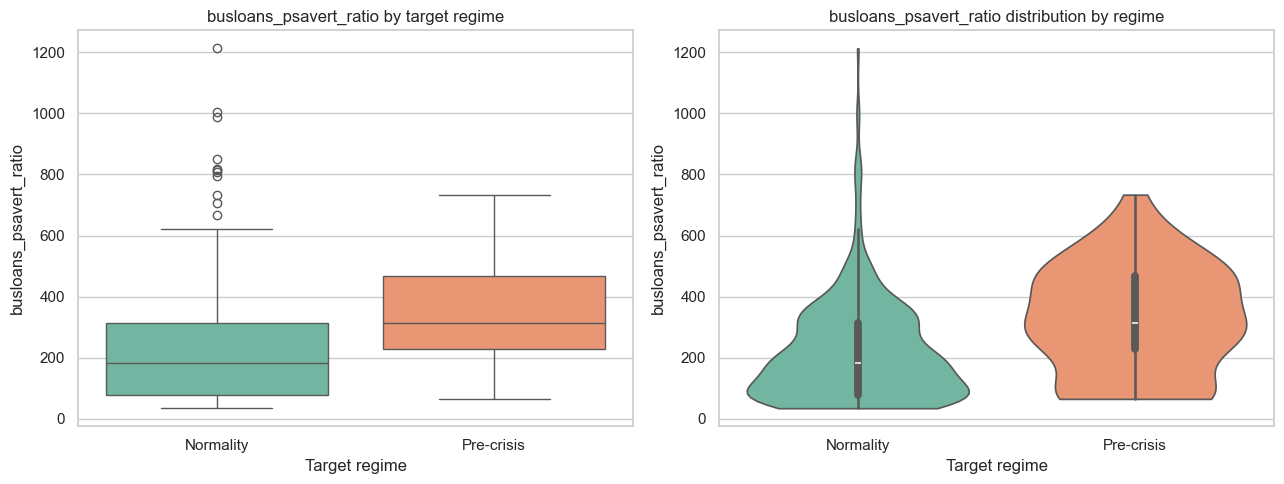

In [8]:
# Boxplots de ratios por régimen de target
boxplot_df = model_df_3[['busloans_psavert_ratio', 'y_crisis_t_plus_18m']].copy()
boxplot_df['target_label'] = boxplot_df['y_crisis_t_plus_18m'].map({0: 'Normality', 1: 'Pre-crisis'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'Normality': '#66c2a5', 'Pre-crisis': '#fc8d62'}

sns.boxplot(
    data=boxplot_df,
    x='target_label',
    y='busloans_psavert_ratio',
    hue='target_label',
    palette=palette,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title('busloans_psavert_ratio by target regime')
axes[0].set_xlabel('Target regime')
axes[0].set_ylabel('busloans_psavert_ratio')

sns.violinplot(
    data=boxplot_df,
    x='target_label',
    y='busloans_psavert_ratio',
    hue='target_label',
    palette=palette,
    dodge=False,
    legend=False,
    ax=axes[1],
    cut=0,
)
axes[1].set_title('busloans_psavert_ratio distribution by regime')
axes[1].set_xlabel('Target regime')
axes[1].set_ylabel('busloans_psavert_ratio')

plt.tight_layout()
plt.show()